In [1]:
import pandas as pd
import numpy as np

In [3]:
# till now
# Timestamp
pd.Timestamp('2032-3-3 9:44')
pd.Timestamp('6th jan 2023 8:10')

Timestamp('2023-01-06 08:10:00')

In [5]:
# DatetimeIndex -> df and series index
pd.DatetimeIndex([pd.Timestamp('2022-3-13'),pd.Timestamp('2022-4-4'),pd.Timestamp('2024-6-23 23:44:44')])

DatetimeIndex(['2022-03-13 00:00:00', '2022-04-04 00:00:00',
               '2024-06-23 23:44:44'],
              dtype='datetime64[ns]', freq=None)

In [7]:
# date_range()
pd.date_range(start='2025-2-2',end='2026-12-12')

DatetimeIndex(['2025-02-02', '2025-02-03', '2025-02-04', '2025-02-05',
               '2025-02-06', '2025-02-07', '2025-02-08', '2025-02-09',
               '2025-02-10', '2025-02-11',
               ...
               '2026-12-03', '2026-12-04', '2026-12-05', '2026-12-06',
               '2026-12-07', '2026-12-08', '2026-12-09', '2026-12-10',
               '2026-12-11', '2026-12-12'],
              dtype='datetime64[ns]', length=679, freq='D')

In [8]:
# to_datetime()
s = pd.Series(['2023/1/6','2023/1/7','2023/1/7'])
pd.to_datetime(s).dt.day_name()

0      Friday
1    Saturday
2    Saturday
dtype: object

### Timedelta Object

Represents a duration, the difference between two dates or times.

In [10]:
# create using Timestamp objects
t1 = pd.Timestamp('2004-2-3')
t2 = pd.Timestamp('2025-3-31')

t2 - t1

Timedelta('7727 days 00:00:00')

In [13]:
import pandas as pd
from dateutil.relativedelta import relativedelta

t1 = pd.Timestamp('2007-1-1')
t2 = pd.Timestamp('2026-3-31')

diff = relativedelta(t2, t1)

print(diff.years, "years", diff.months, "months", diff.days, "days")

19 years 2 months 30 days


In [20]:
# standalone creation
a = pd.Timedelta(days = 3, hours=4, minutes = 55)

In [26]:
td = pd.Timedelta(days=3, hours=4, minutes=55)

td.total_seconds()

276900.0

In [27]:
# Arithmetic
pd.Timestamp('6th jan 2023') + pd.Timedelta(days=2,hours=10,minutes=35)

Timestamp('2023-01-08 10:35:00')

In [28]:
pd.date_range(start='2023-1-6',end='2023-1-31',freq='D') - pd.Timedelta(days=2,hours=10,minutes=35)

DatetimeIndex(['2023-01-03 13:25:00', '2023-01-04 13:25:00',
               '2023-01-05 13:25:00', '2023-01-06 13:25:00',
               '2023-01-07 13:25:00', '2023-01-08 13:25:00',
               '2023-01-09 13:25:00', '2023-01-10 13:25:00',
               '2023-01-11 13:25:00', '2023-01-12 13:25:00',
               '2023-01-13 13:25:00', '2023-01-14 13:25:00',
               '2023-01-15 13:25:00', '2023-01-16 13:25:00',
               '2023-01-17 13:25:00', '2023-01-18 13:25:00',
               '2023-01-19 13:25:00', '2023-01-20 13:25:00',
               '2023-01-21 13:25:00', '2023-01-22 13:25:00',
               '2023-01-23 13:25:00', '2023-01-24 13:25:00',
               '2023-01-25 13:25:00', '2023-01-26 13:25:00',
               '2023-01-27 13:25:00', '2023-01-28 13:25:00'],
              dtype='datetime64[ns]', freq='D')

In [29]:
# real life example
df = pd.read_csv('deliveries1.csv')
df.head()

,order_date,delivery_date
0,5/24/98,2/5/99
1,4/22/92,3/6/98
2,2/10/91,8/26/92
3,7/21/92,11/20/97
4,9/2/93,6/10/98


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_date     501 non-null    object
 1   delivery_date  501 non-null    object
dtypes: object(2)
memory usage: 8.0+ KB


In [34]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_date     501 non-null    datetime64[ns]
 1   delivery_date  501 non-null    datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 8.0 KB


In [35]:
df['delivery_time_period'] = df['delivery_date'] - df['order_date']

df['delivery_time_period'].mean()

Timedelta('1217 days 22:53:53.532934128')

In [36]:
df

,order_date,delivery_date,delivery_time_period
0,1998-05-24,1999-02-05,257 days
1,1992-04-22,1998-03-06,2144 days
2,1991-02-10,1992-08-26,563 days
3,1992-07-21,1997-11-20,1948 days
4,1993-09-02,1998-06-10,1742 days
...,...,...,...
496,1991-06-24,1996-02-02,1684 days
497,1991-09-09,1998-03-30,2394 days
498,1990-11-16,1998-04-27,2719 days
499,1993-06-03,1993-06-13,10 days


### Time series

A time series is a data set that tracks a sample over time. In particular, a time series allows one to see what factors influence certain variables from period to period. Time series analysis can be useful to see how a given asset, security, or economic variable changes over time.

Examples

- Financial Data (Company stocks)
- Natural Data (Rainfall measurement)
- Event Data (Covid)
- Medical Data (Heart rate monitoring)

Types of Operations done on Time Series

- Time Series Analysis
- Time Series Forecasting

In [37]:
google = pd.read_csv('google.csv')
google.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361
1,2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874
2,2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897
3,2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808
4,2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276


In [38]:
google.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4471 entries, 0 to 4470
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4471 non-null   object 
 1   Open       4471 non-null   float64
 2   High       4471 non-null   float64
 3   Low        4471 non-null   float64
 4   Close      4471 non-null   float64
 5   Adj Close  4471 non-null   float64
 6   Volume     4471 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 244.6+ KB


In [39]:
subs = pd.read_csv('subscribers.csv')
views = pd.read_csv('views.csv')
wt = pd.read_csv('watch-time.csv')
comments = pd.read_csv('comments.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'subscribers.csv'

In [40]:
google['Date'] = pd.to_datetime(google['Date'])
google.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4471 entries, 0 to 4470
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4471 non-null   datetime64[ns]
 1   Open       4471 non-null   float64       
 2   High       4471 non-null   float64       
 3   Low        4471 non-null   float64       
 4   Close      4471 non-null   float64       
 5   Adj Close  4471 non-null   float64       
 6   Volume     4471 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 244.6 KB


In [41]:
google.set_index('Date',inplace=True)

In [42]:
google.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100
2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800
2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100
2022-05-19,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600
2022-05-20,2241.709961,2251.000000,2127.459961,2186.260010,2186.260010,1878100


In [45]:
google.loc['2022-05-16']

Open         2.307680e+03
High         2.332150e+03
Low          2.286700e+03
Close        2.295850e+03
Adj Close    2.295850e+03
Volume       1.164100e+06
Name: 2022-05-16 00:00:00, dtype: float64

In [46]:
# partial indexing -> select a particular year/month
google.loc['2022']

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-01-03,2889.510010,2911.000000,2870.050049,2901.489990,2901.489990,1260700
2022-01-04,2911.010010,2932.199951,2876.322998,2888.330078,2888.330078,1146400
2022-01-05,2883.620117,2885.959961,2750.469971,2753.070068,2753.070068,2482100
2022-01-06,2749.949951,2793.719971,2735.270020,2751.020020,2751.020020,1452500
2022-01-07,2758.100098,2765.094971,2715.780029,2740.090088,2740.090088,970400
...,...,...,...,...,...,...
2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100
2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800
2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100


In [47]:
google['month_name'] = google.index.month_name()
google['weekday_name'] = google.index.day_name()
google['quarter'] = google.index.quarter

google.head()

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897,August,Monday,3
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808,August,Tuesday,3
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276,August,Wednesday,3


In [48]:
# challenge -> fetch info for a particular date every year -> limitation of timedelta
google.head()


google[google.index.isin(pd.date_range(start='2005-1-6',end='2022-1-6',freq=pd.DateOffset(years=1)))]

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2005-01-06,97.175758,97.584229,93.509506,93.922951,93.922951,20852067,January,Thursday,1
2006-01-06,227.581970,234.371521,225.773743,231.960556,231.960556,35646914,January,Friday,1
2009-01-06,165.868286,169.763687,162.585587,166.406265,166.406265,12898566,January,Tuesday,1
2010-01-06,311.761444,311.761444,302.047852,302.994293,302.994293,7987226,January,Wednesday,1
2011-01-06,304.199799,308.060303,303.885956,305.604523,305.604523,4131026,January,Thursday,1
2012-01-06,328.344299,328.767700,323.681763,323.796326,323.796326,5405987,January,Friday,1
2014-01-06,554.426880,557.340942,551.154114,556.573853,556.573853,3551864,January,Monday,1
2015-01-06,513.589966,514.761719,499.678131,500.585632,500.585632,2899940,January,Tuesday,1
2016-01-06,730.000000,747.179993,728.919983,743.619995,743.619995,1947000,January,Wednesday,1


<Axes: xlabel='Date'>

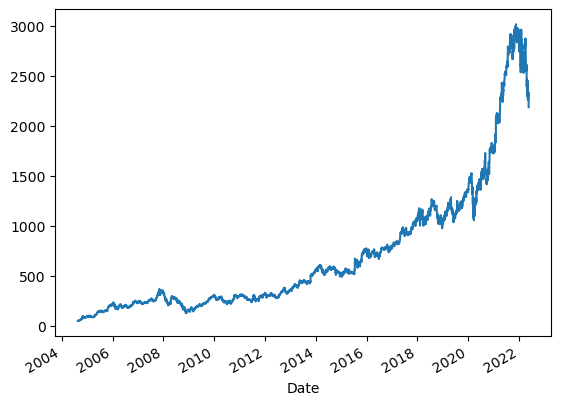

In [49]:
# viz a single col
google['Close'].plot()